In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import re

## Config

In [2]:
# Paths
TBD_TEST_PATH    = "/kaggle/input/datasets/nhhongg/tbd-origin/test.csv"
MATRES_TEST_PATH = "/kaggle/input/datasets/nhhongg/matres/test.csv"
TBD_MODEL_PATH   = "/kaggle/input/datasets/nhhongg/model-test/model_final_roberta_seed_42.pth"
MATRES_MODEL_PATH= "/kaggle/input/datasets/nhhongg/model-test/geotre_matres_latest_roberta_model_seed_567.pth"

# Labels
TBD_LABEL_NAMES    = ["BEFORE", "AFTER", "INCLUDES", "IS_INCLUDED", "SIMULTANEOUS", "VAGUE"]
MATRES_LABEL_NAMES = ["BEFORE", "AFTER", "EQUAL", "VAGUE"]

TBD_LABEL_MAP    = {n: i for i, n in enumerate(TBD_LABEL_NAMES)}
MATRES_LABEL_MAP = {n: i for i, n in enumerate(MATRES_LABEL_NAMES)}

TBD_VAGUE_IDX    = 5
MATRES_VAGUE_IDX = 3
TBD_EVAL_LABELS    = list(range(5))
MATRES_EVAL_LABELS = list(range(3))
TBD_NUM_CLASSES    = 6
MATRES_NUM_CLASSES = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Load data

In [3]:
# TBD
tbd_test_df = pd.read_csv(TBD_TEST_PATH)
tbd_test_df = tbd_test_df[tbd_test_df["label"] != "VAGUE"].reset_index(drop=True)

# MATRES
matres_test_df = pd.read_csv(MATRES_TEST_PATH)
matres_test_df = matres_test_df[matres_test_df["label"] != "VAGUE"].reset_index(drop=True)

print("TBD test (đã loại VAGUE)")
print(tbd_test_df["label"].value_counts())
print(f"Total: {len(tbd_test_df)}")

print("\n MATRES test (đã loại VAGUE)")
print(matres_test_df["label"].value_counts())
print(f"Total: {len(matres_test_df)}")

TBD test (đã loại VAGUE)
label
BEFORE          384
AFTER           274
INCLUDES         56
IS_INCLUDED      53
SIMULTANEOUS     22
Name: count, dtype: int64
Total: 789

 MATRES test (đã loại VAGUE)
label
BEFORE    413
AFTER     265
EQUAL      31
Name: count, dtype: int64
Total: 709


## Preprocessing

In [4]:
def insert_tags_fast(text_chunk, s1, e1, s2, e2):
    insertions = [(s1, "<e1>"), (e1, "</e1>"), (s2, "<e2>"), (e2, "</e2>")]
    insertions.sort(key=lambda x: x[0], reverse=True)
    text_list = list(text_chunk)
    for pos, tag in insertions:
        if pos == -1: continue
        pos = max(0, min(len(text_list), pos))
        text_list.insert(pos, tag)
    return "".join(text_list)

def find_boundary(text, idx, direction="left"):
    limit = 50
    if direction == "left":
        start = max(0, idx - limit)
        sub = text[start:idx]
        matches = list(re.finditer(r"[\s\.]", sub))
        return start + matches[-1].end() if matches else idx
    else:
        end = min(len(text), idx + limit)
        sub = text[idx:end]
        matches = list(re.finditer(r"[\s\.]", sub))
        return idx + matches[0].start() if matches else idx

def create_chunk(full_text, s1, e1, s2, e2, max_len=256):
    span_start = min(s1, s2); span_end = max(e1, e2)
    dist = span_end - span_start
    max_char_len = (max_len - 10) * 3
    if dist > max_char_len:
        pad = 50
        c1_s = max(0, s1-pad); c1_e = min(len(full_text), e1+pad)
        c2_s = max(0, s2-pad); c2_e = min(len(full_text), e2+pad)
        chunk1 = insert_tags_fast(full_text[c1_s:c1_e], s1-c1_s, e1-c1_s, -1, -1)
        chunk2 = insert_tags_fast(full_text[c2_s:c2_e], -1, -1, s2-c2_s, e2-c2_s)
        return chunk1 + " [SEP] " + chunk2
    remaining = max_char_len - dist
    pad = int(remaining / 2)
    raw_start = max(0, span_start - pad)
    raw_end   = min(len(full_text), span_end + pad)
    final_start = find_boundary(full_text, raw_start, "left")
    final_end   = find_boundary(full_text, raw_end, "right")
    return insert_tags_fast(full_text[final_start:final_end],
                            s1-final_start, e1-final_start,
                            s2-final_start, e2-final_start)

def preprocess_df(df):
    tqdm.pandas(desc="Processing")
    df["processed_text"] = df.progress_apply(
        lambda r: create_chunk(r["text"],
                               r["entity1_start"], r["entity1_end"],
                               r["entity2_start"], r["entity2_end"]),
        axis=1,
    )
    return df

print("Preprocessing TBD...")
tbd_test_df = preprocess_df(tbd_test_df)
print("Preprocessing MATRES...")
matres_test_df = preprocess_df(matres_test_df)

Preprocessing TBD...


Processing: 100%|██████████| 789/789 [00:00<00:00, 26509.01it/s]


Preprocessing MATRES...


Processing: 100%|██████████| 709/709 [00:00<00:00, 44010.74it/s]


## Dataset

In [5]:
class GeoDataset(Dataset):
    def __init__(self, dataframe, tokenizer, label_map, max_length=256):
        self.data      = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.label_map = label_map
        self.max_length= max_length

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        enc = self.tokenizer(
            row["processed_text"], add_special_tokens=True,
            max_length=self.max_length, padding="max_length",
            truncation=True, return_tensors="pt",
        )
        ids  = enc["input_ids"].flatten()
        mask = enc["attention_mask"].flatten()
        tti  = torch.zeros_like(ids)

        e1_id = self.tokenizer.convert_tokens_to_ids("<e1>")
        e2_id = self.tokenizer.convert_tokens_to_ids("<e2>")

        def find_pos(ids, t):
            m = (ids == t).nonzero(as_tuple=False)
            return m[0][0] if len(m) > 0 else torch.tensor(0)

        return {
            "input_ids":      ids,
            "attention_mask": mask,
            "token_type_ids": tti,
            "labels": torch.tensor(self.label_map.get(row["label"], -1), dtype=torch.long),
            "e1_pos": find_pos(ids, e1_id),
            "e2_pos": find_pos(ids, e2_id),
        }

def collate_fn(batch):
    return {
        "input_ids":      torch.stack([b["input_ids"]      for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
        "token_type_ids": torch.stack([b["token_type_ids"] for b in batch]),
        "labels":         torch.stack([b["labels"]         for b in batch]),
        "e1_pos":         torch.stack([b["e1_pos"]         for b in batch]),
        "e2_pos":         torch.stack([b["e2_pos"]         for b in batch]),
    }

## Tokenizer

In [6]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
tokenizer.add_special_tokens(
    {"additional_special_tokens": ["<e1>", "</e1>", "<e2>", "</e2>"]}
)
print("Tokenizer loaded.")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded.


## Model

In [7]:
class GeoTREModel(nn.Module):
    def __init__(self, model_name="roberta-base", num_classes=6,
                 hidden=256, dropout=0.2, topk=5):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden_size     = self.encoder.config.hidden_size
        self.topk       = topk
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_size, num_heads=8,
            dropout=dropout, batch_first=True)
        self.proj = nn.Sequential(
            nn.Linear(hidden_size*2, hidden_size), nn.LayerNorm(hidden_size),
            nn.ReLU(), nn.Dropout(dropout))
        self.geo_head = nn.Sequential(
            nn.Linear(hidden_size, hidden), nn.LayerNorm(hidden),
            nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, 2))
        self.cls_head = nn.Sequential(
            nn.Linear(hidden_size*2, hidden), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden, num_classes))
        self.vague_head = nn.Sequential(
            nn.Linear(hidden_size*2, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, 2))
        self.simul_threshold = nn.Parameter(torch.tensor(-2.0))
        self.geo_temp        = nn.Parameter(torch.tensor(0.0))

    def _event_repr(self, H, pos_idx, mask=None):
        B   = H.size(0)
        h   = H[torch.arange(B), pos_idx]
        kpm = (mask == 0) if mask is not None else None
        _, attn = self.cross_attn(query=h.unsqueeze(1), key=H, value=H,
                                  key_padding_mask=kpm)
        w = attn.squeeze(1)
        tw, ti = w.topk(self.topk, dim=-1)
        tw = tw / (tw.sum(-1, keepdim=True) + 1e-9)
        tv = H[torch.arange(B).unsqueeze(1).expand_as(ti), ti]
        h_rich = self.proj(torch.cat([h, (tw.unsqueeze(-1)*tv).sum(1)], dim=-1))
        out = self.geo_head(h_rich)
        s = out[:, 0]
        e = s + F.softplus(out[:, 1]) + 0.05
        return s, e, h_rich

    def forward(self, input_ids, attention_mask, e1_pos, e2_pos,
                token_type_ids=None):
        H = self.encoder(input_ids=input_ids,
                         attention_mask=attention_mask).last_hidden_state
        s1, e1, h1 = self._event_repr(H, e1_pos, attention_mask)
        s2, e2, h2 = self._event_repr(H, e2_pos, attention_mask)
        logits_sem   = self.cls_head(torch.cat([h1, h2], dim=1))
        logits_geo   = None
        logits_vague = self.vague_head(torch.cat([h1, h2], dim=1))
        return s1, e1, s2, e2, logits_sem, logits_geo, logits_vague

## Load model

In [8]:
def load_model(path, num_classes):
    m = GeoTREModel(num_classes=num_classes)
    m.encoder.resize_token_embeddings(len(tokenizer))
    m.load_state_dict(torch.load(path, map_location=device))
    m.to(device)
    m.eval()
    return m

tbd_model    = load_model(TBD_MODEL_PATH,    TBD_NUM_CLASSES)
matres_model = load_model(MATRES_MODEL_PATH, MATRES_NUM_CLASSES)
print("TBD model loaded.")
print("MATRES model loaded.")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, 

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TBD model loaded.
MATRES model loaded.


## INFERENCE

In [9]:
def run_inference(model, df, label_map, batch_size=32):
    dataset = GeoDataset(df, tokenizer, label_map)
    loader  = DataLoader(dataset, batch_size=batch_size,
                         shuffle=False, collate_fn=collate_fn)
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Inference"):
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            e1p  = batch["e1_pos"].to(device)
            e2p  = batch["e2_pos"].to(device)
            _, _, _, _, logits_sem, _, _ = model(ids, mask, e1p, e2p)
            all_logits.append(logits_sem.cpu())
            all_labels.extend(batch["labels"].numpy())
    logits = torch.cat(all_logits)
    labels = np.array(all_labels)
    preds  = logits.argmax(dim=-1).numpy()
    return logits, labels, preds

print("=== Inference TBD ===")
tbd_logits, tbd_labels, tbd_preds = run_inference(
    tbd_model, tbd_test_df, TBD_LABEL_MAP)

print("=== Inference MATRES ===")
matres_logits, matres_labels, matres_preds = run_inference(
    matres_model, matres_test_df, MATRES_LABEL_MAP)

=== Inference TBD ===


Inference: 100%|██████████| 25/25 [00:11<00:00,  2.25it/s]


=== Inference MATRES ===


Inference: 100%|██████████| 23/23 [00:08<00:00,  2.63it/s]


## Kết quả mô hình (ko tính vague)

In [10]:
def print_metrics(labels, preds, eval_labels, label_names, vague_idx, title):
    mask = labels != vague_idx
    micro = f1_score(labels[mask], preds[mask], labels=eval_labels,
                     average="micro", zero_division=0)
    macro = f1_score(labels[mask], preds[mask], labels=eval_labels,
                     average="macro", zero_division=0)
    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"  Micro-F1: {micro:.4f}  |  Macro-F1: {macro:.4f}")
    print(f"{'='*50}")
    print(classification_report(
        labels[mask], preds[mask],
        labels=eval_labels,
        target_names=label_names[:-1],
        zero_division=0, digits=4,
    ))

print_metrics(tbd_labels, tbd_preds,
              TBD_EVAL_LABELS, TBD_LABEL_NAMES, TBD_VAGUE_IDX, "TBD")

print_metrics(matres_labels, matres_preds,
              MATRES_EVAL_LABELS, MATRES_LABEL_NAMES, MATRES_VAGUE_IDX, "MATRES")


  TBD
  Micro-F1: 0.8596  |  Macro-F1: 0.6768
              precision    recall  f1-score   support

      BEFORE     0.9028    0.9193    0.9110       384
       AFTER     0.9583    0.8394    0.8949       274
    INCLUDES     0.7209    0.5536    0.6263        56
 IS_INCLUDED     0.7556    0.6415    0.6939        53
SIMULTANEOUS     0.4444    0.1818    0.2581        22

   micro avg     0.8956    0.8264    0.8596       789
   macro avg     0.7564    0.6271    0.6768       789
weighted avg     0.8865    0.8264    0.8524       789


  MATRES
  Micro-F1: 0.8161  |  Macro-F1: 0.6150
              precision    recall  f1-score   support

      BEFORE     0.9152    0.8620    0.8878       413
       AFTER     0.8366    0.8113    0.8238       265
       EQUAL     0.1017    0.1935    0.1333        31

   micro avg     0.8184    0.8138    0.8161       709
   macro avg     0.6178    0.6223    0.6150       709
weighted avg     0.8502    0.8138    0.8309       709



## Phân tích Vague predictions

In [11]:
def vague_analysis(labels, preds, vague_idx, label_names, title):
    num_vague = (preds == vague_idx).sum()
    total     = len(preds)
    print(f"\n{'='*50}")
    print(f"  {title} — Predict VAGUE")
    print(f"{'='*50}")
    print(f"  Số mẫu predict thành VAGUE: {num_vague}/{total} ({num_vague/total:.4f})")

    cm = confusion_matrix(labels, preds,
                          labels=list(range(len(label_names))))
    print(f"\n  Phân bố lỗi -> VAGUE theo gold label:")
    for i, lname in enumerate(label_names[:-1]):
        total_i = cm[i, :].sum()
        vague_i = cm[i, vague_idx]
        print(f"    {lname:15s}: {vague_i:3d}/{total_i} ({vague_i/total_i:.4f})")
    return cm

cm_tbd  = vague_analysis(tbd_labels, tbd_preds,
                           TBD_VAGUE_IDX, TBD_LABEL_NAMES, "TBD")
cm_matres = vague_analysis(matres_labels, matres_preds,
                           MATRES_VAGUE_IDX, MATRES_LABEL_NAMES, "MATRES")


  TBD — Predict VAGUE
  Số mẫu predict thành VAGUE: 61/789 (0.0773)

  Phân bố lỗi -> VAGUE theo gold label:
    BEFORE         :  14/384 (0.0365)
    AFTER          :  27/274 (0.0985)
    INCLUDES       :  10/56 (0.1786)
    IS_INCLUDED    :   5/53 (0.0943)
    SIMULTANEOUS   :   5/22 (0.2273)

  MATRES — Predict VAGUE
  Số mẫu predict thành VAGUE: 4/709 (0.0056)

  Phân bố lỗi -> VAGUE theo gold label:
    BEFORE         :   3/413 (0.0073)
    AFTER          :   0/265 (0.0000)
    EQUAL          :   1/31 (0.0323)


## Confusion matrix

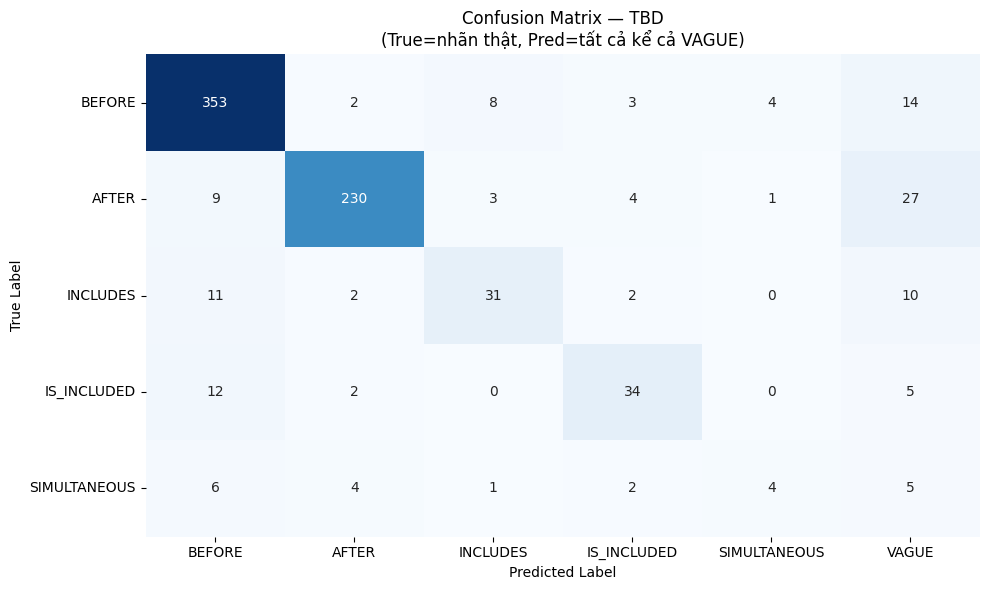

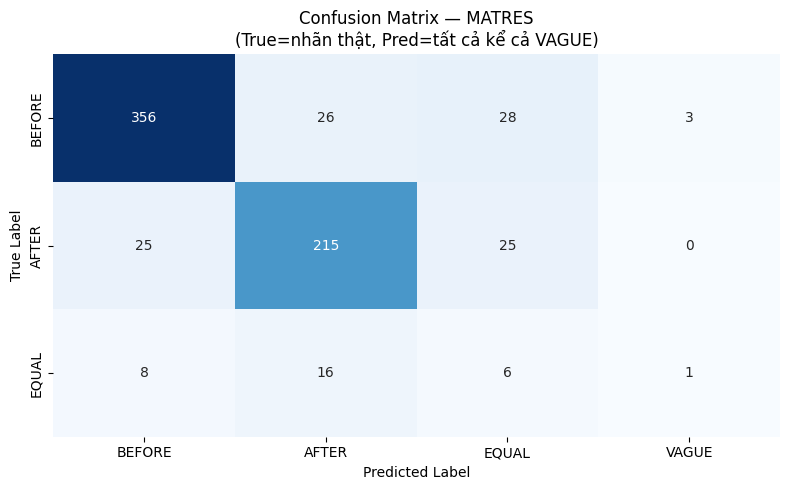

In [12]:
# Hình 1 — TBD
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    cm_tbd[:TBD_VAGUE_IDX, :],
    annot=True, fmt="d", cmap="Blues",
    xticklabels=TBD_LABEL_NAMES,
    yticklabels=TBD_LABEL_NAMES[:TBD_VAGUE_IDX],
    ax=ax, cbar=False,
)
ax.set_title("Confusion Matrix — TBD\n(True=nhãn thật, Pred=tất cả kể cả VAGUE)",
             fontsize=12)
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Hình 2 — MATRES
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    cm_matres[:MATRES_VAGUE_IDX, :],
    annot=True, fmt="d", cmap="Blues",
    xticklabels=MATRES_LABEL_NAMES,
    yticklabels=MATRES_LABEL_NAMES[:MATRES_VAGUE_IDX],
    ax=ax, cbar=False,
)
ax.set_title("Confusion Matrix — MATRES\n(True=nhãn thật, Pred=tất cả kể cả VAGUE)",
             fontsize=12)
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Tổng hợp

In [13]:
print("="*60)
print("  TỔNG HỢP: Tỉ lệ predict VAGUE")
print("="*60)

for title, preds, vague_idx in [
    ("TBD",    tbd_preds,    TBD_VAGUE_IDX),
    ("MATRES", matres_preds, MATRES_VAGUE_IDX),
]:
    n = (preds == vague_idx).sum()
    print(f"  {title:8s}: {n}/{len(preds)} ({n/len(preds):.4f})")

print("="*60)

  TỔNG HỢP: Tỉ lệ predict VAGUE
  TBD     : 61/789 (0.0773)
  MATRES  : 4/709 (0.0056)
